---

Bibliotecas usadas

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

---

Lendo o arquivo .csv para análise

In [2]:
shows = pd.read_csv("TV Shows - Netflix.csv", delimiter=",")
print(shows.head())

            Titles  Year Rating  IMDB_Rating  Netflix
0     Breaking Bad  2008    18+          9.5        1
1  Game of Thrones  2011    18+          9.3        0
2   Rick and Morty  2013    18+          9.2        0
3             Dark  2017    16+          8.8        1
4  Stranger Things  2016    16+          8.8        1


---

As series melhores avaliadas estão na Netflix?


A quantidade de shows na Netflix com nota acima ou igual de 9.0 : 3
A quantidade de shows fora da Netflix com nota acima ou igual de 9.0 : 9


<Axes: >

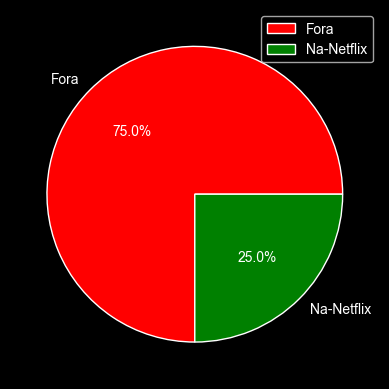

In [3]:
melhoresShows = shows.sort_values(['IMDB_Rating'], ascending=False)

showsNetflix = (melhoresShows['IMDB_Rating'] >= 9.0) & (melhoresShows['Netflix'] == 1)
dfShowsNetflix = melhoresShows.loc[showsNetflix]
qtdShowsNetflix = len(dfShowsNetflix)

showsFora = (melhoresShows['IMDB_Rating'] >= 9.0) & (melhoresShows['Netflix'] == 0)
dfShowsFora = melhoresShows.loc[showsFora]
qtdShowsForaNetflix = len(dfShowsFora)

print(f"\nA quantidade de shows na Netflix com nota acima ou igual de 9.0 : {qtdShowsNetflix}")
print(f"A quantidade de shows fora da Netflix com nota acima ou igual de 9.0 : {qtdShowsForaNetflix}")

dataShows = {
    'Status': 'Fora Na-Netflix'.split(),
    'Quantidade': [qtdShowsForaNetflix, qtdShowsNetflix],
}
dfShows = pd.DataFrame(dataShows)

color = ['#FF0000', '#008000']
dfShows.set_index('Status').plot(y='Quantidade', kind='pie', colors=color, autopct='%1.1f%%')

Resposta: Com base no Gráfico realizado, podemos observar que os shows com nota iguais ou acima de "9.0" não estão dentro do catálogo da Netflix.

---

Uma maior classificação indicativa gera series melhores avaliadas?

A média da nota dos Shows 18+ é 8.82
A média da nota dos Shows 16+ é 8.57
A média da nota dos Shows 7+ é 8.77


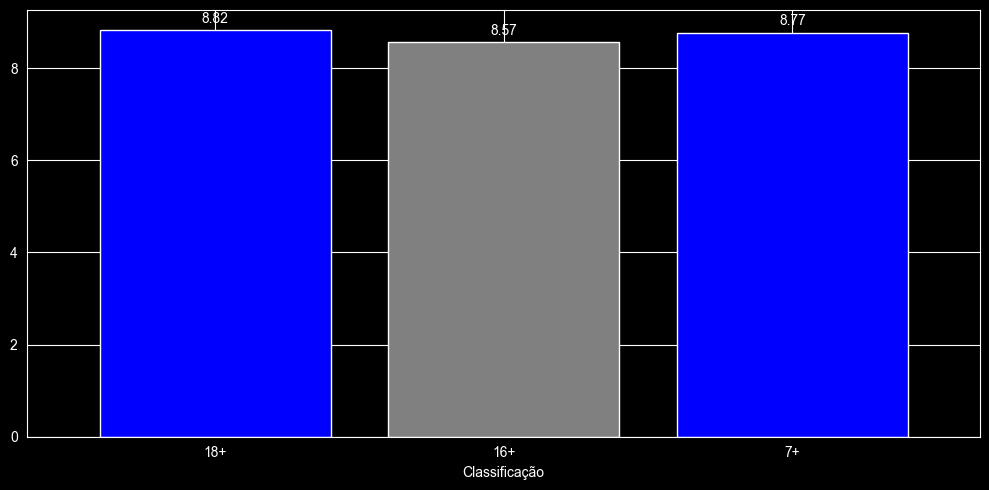

In [4]:
melhoresShows = shows.sort_values(['IMDB_Rating'], ascending=False)

showsAdultos = melhoresShows['Rating'] == '18+'
showsTeen = melhoresShows['Rating'] == '16+'
showsKids = melhoresShows['Rating'] == '7+'

dfShowsAdultos = melhoresShows.loc[showsAdultos]
dfShowsTeen = melhoresShows.loc[showsTeen]
dfShowsKids = melhoresShows.loc[showsKids]

mediaShowsAdultos = dfShowsAdultos['IMDB_Rating'].mean()
mediaShowsTeen = dfShowsTeen['IMDB_Rating'].mean()
mediaShowsKids = dfShowsKids['IMDB_Rating'].mean()

mediaShowsAdultos = round(mediaShowsAdultos, 2)
mediaShowsTeen = round(mediaShowsTeen, 2)
mediaShowsKids = round(mediaShowsKids, 2)

print(f"A média da nota dos Shows 18+ é {mediaShowsAdultos:.2f}")
print(f"A média da nota dos Shows 16+ é {mediaShowsTeen:.2f}")
print(f"A média da nota dos Shows 7+ é {mediaShowsKids:.2f}")

dataShows = {
    'Classificação': '18+ 16+ 7+'.split(),
    'Média de avaliação': [mediaShowsAdultos, mediaShowsTeen,mediaShowsKids],
}
dfShows = pd.DataFrame(dataShows)

color = ['blue', 'gray']
ax = dfShows.plot(x='Classificação', y='Média de avaliação', kind='bar', rot=0, legend=False, color=color, width=0.8,figsize=(10, 5))
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()

Resposta: Considerando que a classificação de shows que estão na faixa etária de "16+", com esse gráfico pode se avaliar que uma maior classificação indicativa não sugere que terão melhores séries, pois como podemos olhar no gráfico, a classificação "7+" pois uma avaliação média maior que a de "16+", estando abaixo apenas das "18+".

---

Quais anos houveram mais lançamentos de series?

Year
2013    6
2017    4
2005    4
2019    4
2015    4
2009    4
2011    3
2016    3
2008    2
2010    2
2002    2
2014    2
2004    2
2007    2
1994    1
2001    1
1999    1
1989    1
1997    1
2006    1
Name: count, dtype: int64


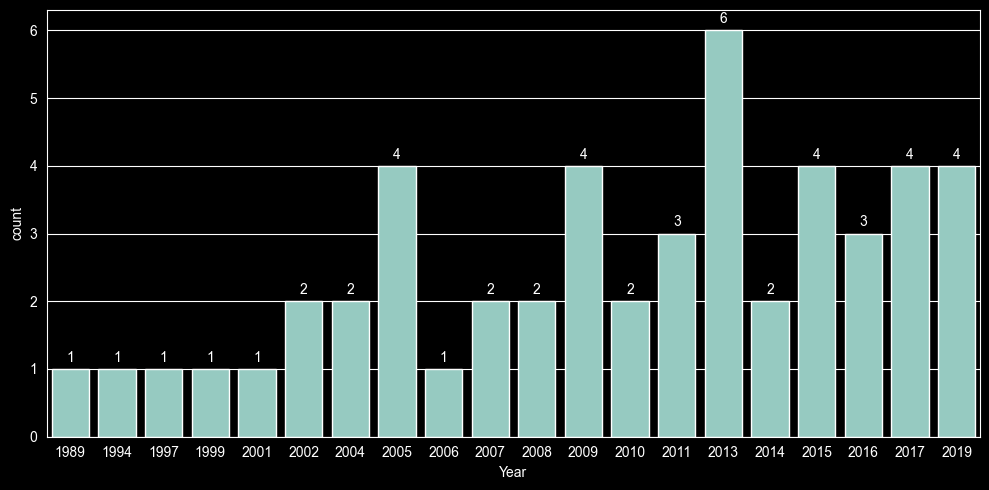

In [5]:
anosShows = shows['Year'].value_counts()
print(anosShows)

plt.figure(figsize=(10,5))
ax = sns.countplot(data=shows, x="Year")
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()

Resposta: O ano que houve mais series lançadas foi o ano de 2013, com 6 lançamentos, seguidos dos anos 2017, 2005, 2019, 2015, 2009, com 4 lançamentos.

---

Quais anos lançaram as series melhores avaliadas?

                              Titles  Year Rating  IMDB_Rating  Netflix
0                       Breaking Bad  2008    18+          9.5        1
1                    Game of Thrones  2011    18+          9.3        0
2                     Rick and Morty  2013    18+          9.2        0
5         Avatar: The Last Airbender  2005     7+          9.2        1
6                           Sherlock  2010    16+          9.1        1
7                          Chernobyl  2019    18+          9.4        0
11                          The Wire  2002    18+          9.3        0
15                  Band of Brothers  2001    18+          9.4        0
22                      The Sopranos  1999    18+          9.2        0
29                    True Detective  2014    18+          9.0        0
43                           Firefly  2002    16+          9.0        0
45  Fullmetal Alchemist: Brotherhood  2009    18+          9.1        0


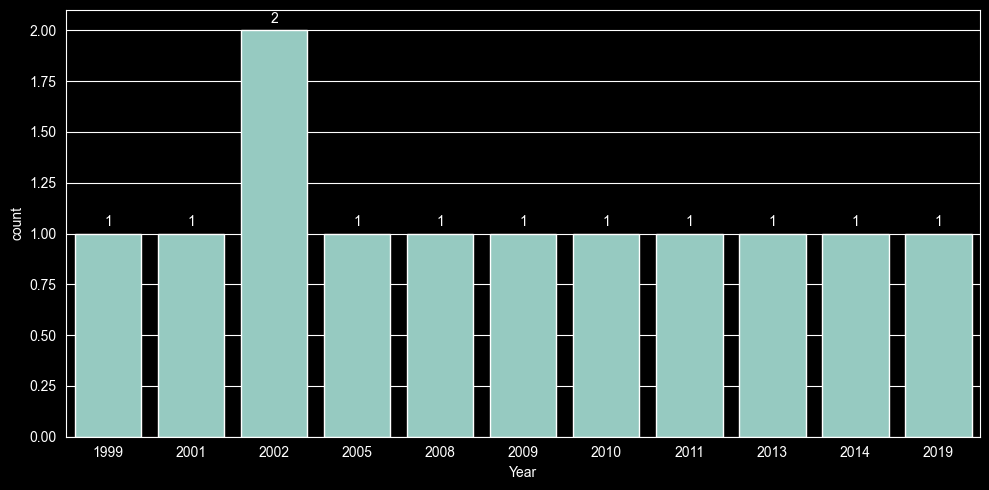

In [6]:
melhoresShows = shows['IMDB_Rating'] >= 9.0
dfMelhoresShows = shows.loc[melhoresShows]
print(dfMelhoresShows)

plt.figure(figsize=(10,5))
ax = sns.countplot(data=dfMelhoresShows, x="Year")
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()

Resposta: Com base no gráfico, o ano que mais teve lançamentos que nota acima de 9.0 no IMDB foi o ano de 2002, com dois shows, o restante dos anos, ficaram empatados com 1.

---

Series novas são piores avaliadas?

A média da nota dos Shows lançados depois do ano de 2016: 8.56
A média de nota dos Shows lançados antes do ano de 2016: 8.75


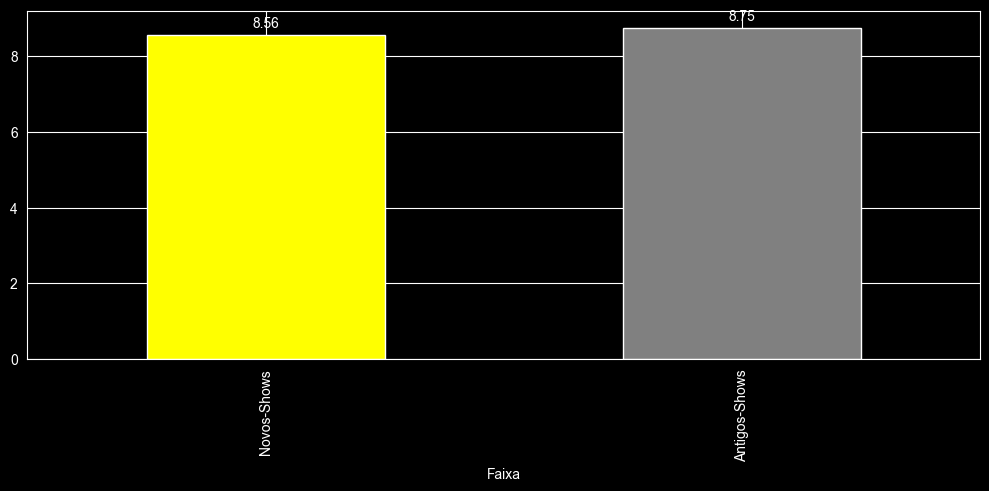

In [7]:
novosShows = shows['Year'] >= 2016
dfNovosShows = shows.loc[novosShows]

velhosShows = shows['Year'] < 2017
dfVelhosShows = shows.loc[velhosShows]

mediaNovosShows = dfNovosShows['IMDB_Rating'].mean()
mediaVelhosShows = dfVelhosShows['IMDB_Rating'].mean()

mediaNovosShows = round(mediaNovosShows, 2)
mediaVelhosShows = round(mediaVelhosShows, 2)

print(f"A média da nota dos Shows lançados depois do ano de 2016: {mediaNovosShows}")
print(f"A média de nota dos Shows lançados antes do ano de 2016: {mediaVelhosShows}")

dataShows = {
    'Faixa': 'Novos-Shows Antigos-Shows'.split(),
    'Media': [mediaNovosShows, mediaVelhosShows],
}
dfDataShows = pd.DataFrame(dataShows)

color = ['yellow', 'gray']
ax = dfDataShows.plot(x='Faixa', y='Media', color=color, legend=False, figsize=(10, 5), kind='bar')
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()

Resposta: Com base no gráfico, podemos obsersar que os Shows que foram lançados antes dos do ano de 2016, são levemente melhores avaliados em média, com a média de 8.75 em comparação com a média de 8.56 dos Shows lançados após o ano de 2016

---

Quais décadas há mais shows?

  Década  Quantidade
3   2010          26
2   2000          20
1   1990           3
0   1980           1


<Axes: xlabel='Década'>

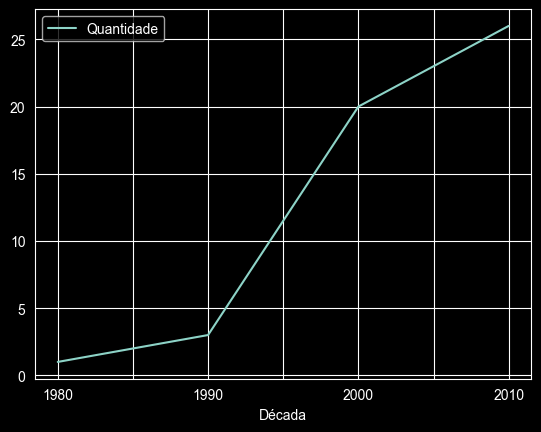

In [28]:
oitenta = ((shows['Year'] >= 1981) & (shows['Year'] <= 1990)).sum()
noventa = ((shows['Year'] >= 1991) & (shows['Year'] <= 2000)).sum()
doismil = ((shows['Year'] >= 2001) & (shows['Year'] <= 2010)).sum()
miledez = ((shows['Year'] >= 2011) & (shows['Year'] <= 2020)).sum()

decadas = {
    'Década':'1980 1990 2000 2010'.split(),
    'Quantidade':[oitenta, noventa, doismil, miledez]
}
dfDecadas = pd.DataFrame(decadas)
dfDecadasOrd = dfDecadas.sort_values(['Quantidade'], ascending=False)
print(dfDecadasOrd)

dfDecadas.plot(x='Década', y='Quantidade', kind='line')

Resposta: Com base no gráfico, podemos ver que a década de 2010 foi a que mais possui shows lançados com um total de 26 séries, podemos observar também que houve um aumento de séries lançadas ao decorrer das décadas.

---

Qual década tem os melhores shows?

  Década  Média
1   1990   8.93
2   2000   8.75
0   1980   8.70
3   2010   8.67


<Axes: xlabel='Década'>

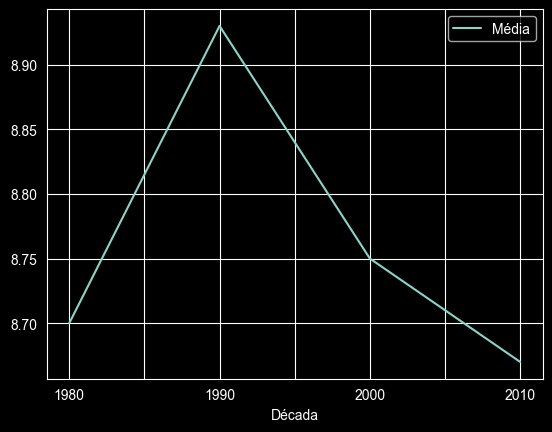

In [40]:
oitenta = ((shows['Year'] >= 1981) & (shows['Year'] <= 1990))
noventa = ((shows['Year'] >= 1991) & (shows['Year'] <= 2000))
doismil = ((shows['Year'] >= 2001) & (shows['Year'] <= 2010))
miledez = ((shows['Year'] >= 2011) & (shows['Year'] <= 2020))

dfOitenta = shows.loc[oitenta]
dfNoventa = shows.loc[noventa]
dfDoismil = shows.loc[doismil]
dfMiledez = shows.loc[miledez]

mediaOitenta = dfOitenta['IMDB_Rating'].mean()
mediaNoventa = dfNoventa['IMDB_Rating'].mean()
mediaDoismil = dfDoismil['IMDB_Rating'].mean()
mediaMiledez = dfMiledez['IMDB_Rating'].mean()

mediaOitenta = round(mediaOitenta, 2)
mediaNoventa = round(mediaNoventa, 2)
mediaDoismil = round(mediaDoismil, 2)
mediaMiledez = round(mediaMiledez, 2)

decadas = {
    'Década':'1980 1990 2000 2010'.split(),
    'Média':[mediaOitenta, mediaNoventa, mediaDoismil, mediaMiledez]
}
dfDecadas = pd.DataFrame(decadas)
dfDecadasOrd = dfDecadas.sort_values(['Média'], ascending=False)
print(dfDecadasOrd)

dfDecadas.plot(x='Década', y='Média', kind='line')

Resposta: Analisando o gráfico, podemos ver que a década de 1990 tem as melhores séries com base em média de avaliação, em seguida vem os anos 2000. Por ter uma quantidade maior de shows lançados nos anos 2010, sua média cai em comparação com outras décadas, por exemplo os anos 80 que teve apenas uma série (analisando o outro relatório) que deixou, sua nota média acima.

---

Qual classificação indicativa há em maioria na Netflix e fora?

  Classificação  Netflix  Fora
0           18+       12    15
1           16+        6    13
2            7+        1     3


<Axes: xlabel='Classificação'>

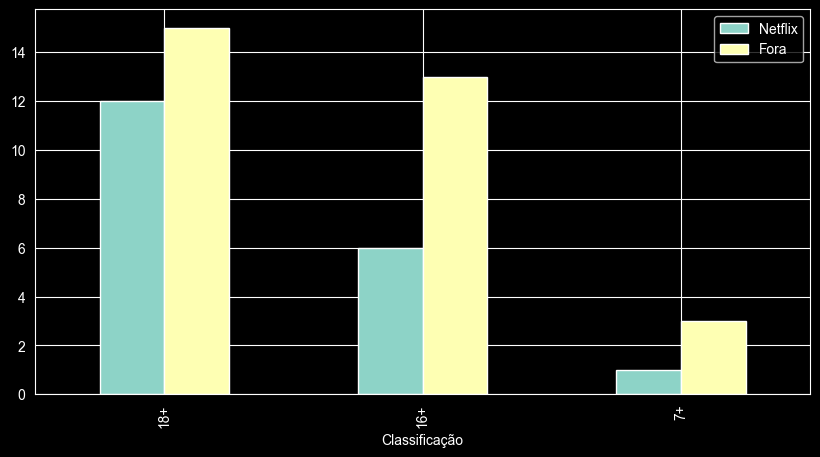

In [8]:
adultosNetflix = ((shows['Rating'] == '18+') & (shows['Netflix'] == 1)).sum()
teensNetflix = ((shows['Rating'] == '16+') & (shows['Netflix'] == 1)).sum()
kidsNetflix = ((shows['Rating'] == '7+') & (shows['Netflix'] == 1)).sum()

adultosFora = ((shows['Rating'] == '18+') & (shows['Netflix'] == 0)).sum()
teensFora = ((shows['Rating'] == '16+') & (shows['Netflix'] == 0)).sum()
kidsFora = ((shows['Rating'] == '7+') & (shows['Netflix'] == 0)).sum()

data = {
    'Classificação':'18+ 16+ 7+'.split(),
    'Netflix':[adultosNetflix, teensNetflix, kidsNetflix],
    'Fora':[adultosFora, teensFora, kidsFora]
}
df = pd.DataFrame(data)
print(df)

df.plot(x='Classificação', y=['Netflix','Fora'], figsize=(10, 5), kind='bar')

Resposta: Com base no gráfico conseguimos ver que a quantidade de filmes que tem uma classificação indicativa (18+) são maioria tanto no catálogo na Netflix quanto fora, em seguida vem a classificação (16+), onde a quantidade de shows fora da Netflix é maior que a quantidade de séries dentro da netflix com a classificação (18+).

---

Qual publico as series recentes estão buscando atualmente?

---

Qual era o publico buscado pelas series antigamente?

---